In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FER2013Dataset(Dataset):
    def __init__(self, csv_path, split='Training', transform=None):
        """
        split can be 'Training', 'PublicTest', or 'PrivateTest'
        """
        self.data = pd.read_csv(csv_path)
        self.data = self.data[self.data['Usage'] == split]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        emotion = row['emotion']
        
        # Convert space-separated pixel string to a 48x48 numpy array
        pixels = np.array(row['pixels'].split(), dtype='float32').reshape(48, 48)
        
        if self.transform:
            pixels = self.transform(pixels)
        else:
            # Add channel dimension (1x48x48) for grayscale
            pixels = torch.tensor(pixels).unsqueeze(0) / 255.0 
            
        return pixels, torch.tensor(emotion, dtype=torch.long)

def get_dataloaders(csv_path, batch_size=64):
    # 1. Train set
    train_dataset = FER2013Dataset(csv_path, split='Training')
    
    # 2. Validation set (used during epochs)
    val_dataset = FER2013Dataset(csv_path, split='PublicTest')
    
    # 3. Final Test set (used only at the very end)
    test_dataset = FER2013Dataset(csv_path, split='PrivateTest') 
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"Loaded CSV -> Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader

In [2]:
# import torch
# import torch.nn as nn
# from kan import KAN

# class KerasBaselineExtractor(nn.Module):
#     """
#     Exact translation of the TensorFlow/Keras CNN backbone from the Jupyter Notebook.
#     Matches the layer shapes and parameter counts perfectly.
#     """
#     def __init__(self):
#         super(KerasBaselineExtractor, self).__init__()
        
#         # PyTorch input shape: (Batch, 1, 48, 48)
#         self.block1 = nn.Sequential(
#             # Keras: Conv2D(64, (3,3), activation='relu') -> Shape: (64, 46, 46)
#             nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=0),
#             nn.ReLU(),
            
#             # Keras: Conv2D(64, (3,3), activation='relu') -> Shape: (64, 44, 44)
#             nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=0),
#             nn.ReLU(),
            
#             # Keras: MaxPooling2D((2,2)) -> Shape: (64, 22, 22)
#             nn.MaxPool2d(kernel_size=2, stride=2),
            
#             # Keras: Dropout(0.2)
#             nn.Dropout(p=0.2)
#         )

#         self.block2 = nn.Sequential(
#             # Keras: Conv2D(128, (3,3), activation='relu') -> Shape: (128, 20, 20)
#             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=0),
#             nn.ReLU(),
            
#             # Keras: MaxPooling2D((2,2)) -> Shape: (128, 10, 10)
#             nn.MaxPool2d(kernel_size=2, stride=2),
            
#             # Keras: Conv2D(128, (3,3), activation='relu') -> Shape: (128, 8, 8)
#             nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=0),
#             nn.ReLU(),
            
#             # Keras: MaxPooling2D((2,2)) -> Shape: (128, 4, 4)
#             nn.MaxPool2d(kernel_size=2, stride=2),
            
#             # Keras: Dropout(0.22)
#             nn.Dropout(p=0.22)
#         )

#         # The final Keras flatten size is 4 * 4 * 128 = 2048 features
#         self.flatten_dim = 2048

#     def forward(self, x):
#         x = self.block1(x)
#         x = self.block2(x)
#         x = torch.flatten(x, 1) # Flatten all dimensions except the batch size
#         return x

# class CNN_KAN(nn.Module):
#     """
#     Your heavy-duty baseline CNN paired with the Kolmogorov-Arnold Network.
#     """
#     def __init__(self, num_classes=7, device='cpu'):
#         super(CNN_KAN, self).__init__()
        
#         # 1. The exact Keras CNN feature extractor
#         self.extractor = KerasBaselineExtractor()
        
#         # 2. The Bottleneck
#         # Your Keras model originally went 2048 -> 512 -> 256 -> 7
#         # Pure KANs are too slow to take 2048 inputs directly. We use a standard 
#         # linear layer to compress the 2048 features down to 64 high-quality signals.
#         self.bottleneck = nn.Sequential(
#             nn.Linear(self.extractor.flatten_dim, 64),
#             nn.ReLU(),
#             nn.Dropout(p=0.5) # Keeping some dropout here helps prevent overfitting
#         )
        
#         # 3. The KAN Classifier (64 inputs -> 7 emotion classes)
#         self.kan_classifier = KAN(width=[64, num_classes], grid=5, k=3, device=device)

#     def forward(self, x):
#         # Extract features (outputs 2048)
#         features = self.extractor(x)
        
#         # Compress features (outputs 64)
#         features = self.bottleneck(features)
        
#         # Classify with splines (outputs 7)
#         return self.kan_classifier(features)

In [3]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from sklearn.metrics import accuracy_score, f1_score
# from tqdm import tqdm

# def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, device='cpu'):
#     model = model.to(device)
#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.Adam(model.parameters(), lr=lr)
    
#     for epoch in range(epochs):
#         model.train()
#         train_loss = 0
        
#         # Training Loop
#         for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
#             images, labels = images.to(device), labels.to(device)
            
#             optimizer.zero_grad()
#             outputs = model(images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
            
#             train_loss += loss.item()
            
#         # Validation Loop
#         model.eval()
#         all_preds = []
#         all_labels = []
#         with torch.no_grad():
#             for images, labels in val_loader:
#                 images, labels = images.to(device), labels.to(device)
#                 outputs = model(images)
#                 _, preds = torch.max(outputs, 1)
                
#                 all_preds.extend(preds.cpu().numpy())
#                 all_labels.extend(labels.cpu().numpy())
                
#         val_acc = accuracy_score(all_labels, all_preds)
#         val_f1 = f1_score(all_labels, all_preds, average='weighted')
        
#         print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        
#     return model

In [4]:
import torch
import torch.nn as nn
from kan import KAN

class HeavyFERExtractor(nn.Module):
    """
    A deep, VGG-style CNN backbone optimized for 48x48 images.
    Uses Batch Normalization to stabilize deep training.
    """
    def __init__(self):
        super(HeavyFERExtractor, self).__init__()
        
        # Block 1: 48x48 -> 24x24
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        
        # Block 2: 24x24 -> 12x12
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        
        # Block 3: 12x12 -> 6x6
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        
        # Block 4: 6x6 -> 3x3
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        # Output is 512 channels of 3x3 feature maps
        self.flatten_dim = 512 * 3 * 3 # 4608 features

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = torch.flatten(x, 1)
        return x

class HeavyCNN_KAN(nn.Module):
    def __init__(self, num_classes=7, device='cpu'):
        super(HeavyCNN_KAN, self).__init__()
        
        self.extractor = HeavyFERExtractor()
        
        # Compress the 4608 deep features down to 64 for the KAN
        self.bottleneck = nn.Sequential(
            nn.Linear(self.extractor.flatten_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )
        
        self.kan_classifier = KAN(width=[64, num_classes], grid=5, k=3, device=device)

    def forward(self, x):
        features = self.extractor(x)
        features = self.bottleneck(features)
        return self.kan_classifier(features)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

def train_model(model, train_loader, val_loader, epochs=40, lr=0.001, device='cpu'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Adding weight decay (L2 penalty) helps prevent the heavy model from overfitting
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # This is the PyTorch equivalent of your Keras ReduceLROnPlateau!
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3, verbose=True)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        # Training Loop
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        # Validation Loop
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        
        print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        
        # Tell the scheduler to check the validation accuracy
        scheduler.step(val_acc)
        
    return model

In [7]:
import torch


def main():
    # Setup
    csv_path = 'fer2013.csv' # Ensure this matches your dataset location
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Load Data
    print("Loading data...")
    train_loader, val_loader,test_loader = get_dataloaders(csv_path, batch_size=64)
    
    # Select Model (Toggle these to test baseline vs proposed)
    # model = BaselineCNN(num_classes=7)
    model = HeavyCNN_KAN(num_classes=7, device=device)
    
    # Train
    print("Starting training...")
    trained_model = train_model(model, train_loader, val_loader, epochs=100, lr=0.001, device=device)
    
    # Save the model
    torch.save(trained_model.state_dict(), "cnn_kan_fer2013.pth")
    print("Training complete and model saved.")

    # --- KAN Interpretability ---
    # If using the CNN_KAN model, you can plot the learned splines!
    # Uncomment the line below after training to visualize the activation functions:
    # trained_model.kan_classifier.plot()

if __name__ == "__main__":
    main()

Using device: cuda
Loading data...
Loaded CSV -> Train: 28709, Val: 3589, Test: 3589


/media/alexmartin/12ab1e1d-f084-44f8-bc16-cfebb77f426f/File-Manager/Program_files/Anaconda/envs/fer_kan/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


checkpoint directory created: ./model
saving model version 0.0
Starting training...


Epoch 1/100: 100%|████████████████████████████| 449/449 [04:02<00:00,  1.85it/s]


Epoch 1 | Train Loss: 1.7469 | Val Acc: 0.4366 | Val F1: 0.3779


...

Epoch 98 | Train Loss: 0.3136 | Val Acc: 0.6679 | Val F1: 0.6685


Epoch 99/100: 100%|███████████████████████████| 449/449 [08:13<00:00,  1.10s/it]


Epoch 99 | Train Loss: 0.3138 | Val Acc: 0.6670 | Val F1: 0.6655


Epoch 100/100: 100%|██████████████████████████| 449/449 [08:19<00:00,  1.11s/it]


Epoch 100 | Train Loss: 0.3138 | Val Acc: 0.6651 | Val F1: 0.6631
Training complete and model saved.


Re-loading dataset...
Loaded CSV -> Train: 28709, Val: 3589, Test: 3589
checkpoint directory created: ./model
saving model version 0.0
Saved weights loaded successfully!
Generating KAN plot...


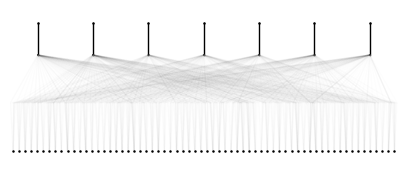

In [9]:
import torch
# Assuming your get_dataloaders function and CNN_KAN class are already defined in the notebook
# If they are in separate files, make sure to: from data_loader import get_dataloaders

# 1. Setup Device and Data Path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_path = 'fer2013.csv' # Make sure this matches your CSV filename/path

# 2. Re-create the test_loader
print("Re-loading dataset...")
_, _, test_loader = get_dataloaders(csv_path, batch_size=64)

# 3. Re-instantiate the model skeleton
trained_model = HeavyCNN_KAN(num_classes=7, device=device)

# 4. Load your trained weights
trained_model.load_state_dict(torch.load("cnn_kan_fer2013.pth", map_location=device, weights_only=True))
trained_model.to(device)
trained_model.eval() 
print("Saved weights loaded successfully!")

# 5. Feed it a single batch of data so the KAN can register the activation ranges
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    _ = trained_model(images) # Dummy forward pass

# 6. Plot the interpretability splines!
print("Generating KAN plot...")
trained_model.kan_classifier.plot()

KAN plot saved to the 'project_visuals' folder!


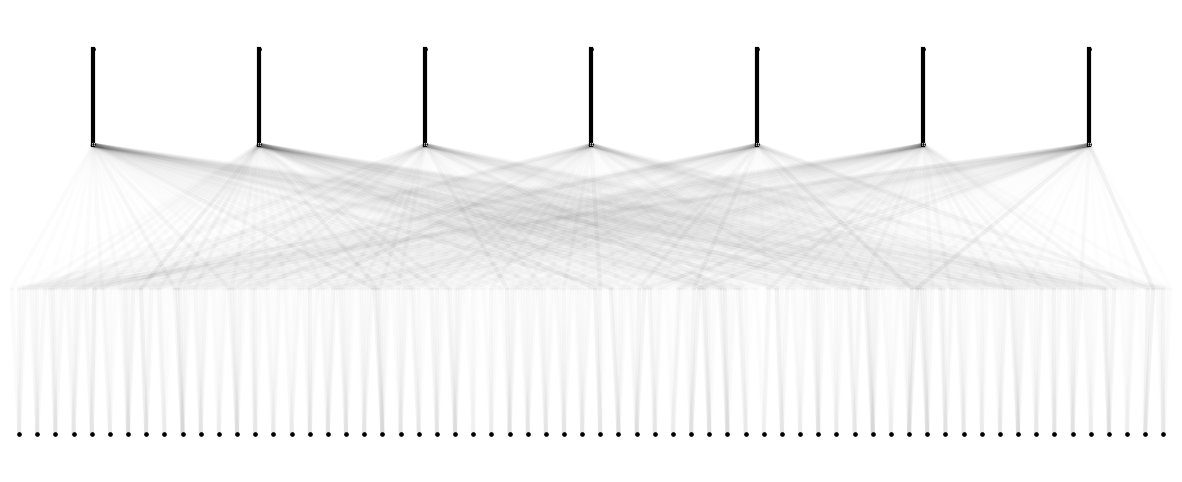

In [10]:
import os

# Create a directory for your project images
os.makedirs("project_visuals", exist_ok=True)

# Plot and save! The 'folder' argument tells pykan to save it there.
# You can also use 'scale' to make the image larger and higher quality.
trained_model.kan_classifier.plot(folder="./project_visuals", scale=1.5)
print("KAN plot saved to the 'project_visuals' folder!")

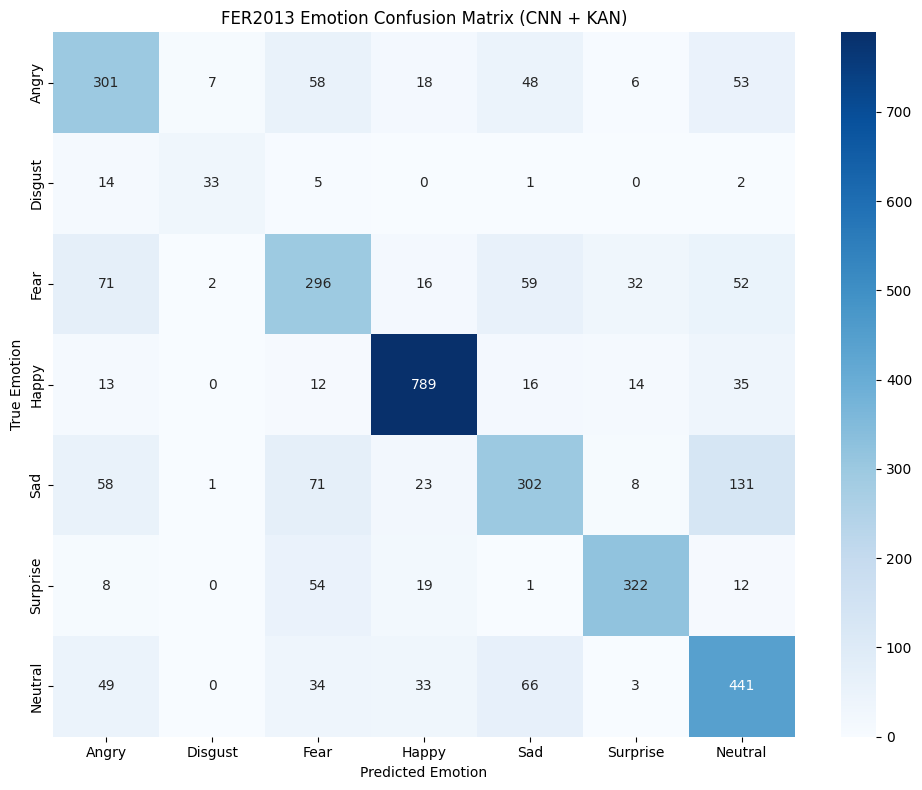

Confusion Matrix saved as 'confusion_matrix.png'!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_and_save_confusion_matrix(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

    # 1. Gather all predictions
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 2. Calculate the matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # 3. Create a visually appealing heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=emotion_labels, yticklabels=emotion_labels)
    plt.title('FER2013 Emotion Confusion Matrix (CNN + KAN)')
    plt.ylabel('True Emotion')
    plt.xlabel('Predicted Emotion')
    plt.tight_layout()

    # 4. Save the plot
    plt.savefig("./project_visuals/confusion_matrix.png", dpi=300)
    plt.show()
    print("Confusion Matrix saved as 'confusion_matrix.png'!")

# Run the function
plot_and_save_confusion_matrix(trained_model, test_loader, device)

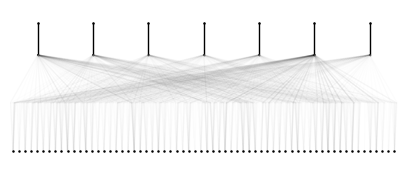

In [12]:
trained_model.kan_classifier.plot()

In [13]:
import torch
from sklearn.metrics import accuracy_score, classification_report

def run_final_test(model, test_loader, device):
    print("\n--- Running Final Test on 'PrivateTest' ---")
    model.eval() # CRITICAL: Put model in evaluation mode
    all_preds = []
    all_labels = []
    
    # Emotion mapping for a readable classification report
    emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
    
    # No gradients needed for testing, saves memory and time
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calculate final metrics
    test_acc = accuracy_score(all_labels, all_preds)
    
    print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")
    print("Detailed Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=emotion_labels))

# --- How to call it in your main script ---
# Assuming 'trained_model' is your finished model and 'test_loader' is ready:
run_final_test(trained_model, test_loader, device)


--- Running Final Test on 'PrivateTest' ---
Final Test Accuracy: 69.21%

Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.59      0.61      0.60       491
     Disgust       0.77      0.60      0.67        55
        Fear       0.56      0.56      0.56       528
       Happy       0.88      0.90      0.89       879
         Sad       0.61      0.51      0.56       594
    Surprise       0.84      0.77      0.80       416
     Neutral       0.61      0.70      0.65       626

    accuracy                           0.69      3589
   macro avg       0.69      0.67      0.68      3589
weighted avg       0.69      0.69      0.69      3589

